# Setup

In [4]:
import torch
from os import path, makedirs
import json
import random

from data_loader import load_data
import numpy as np
from model_loader import get_model
from plotter.plotter import Plotter
from ucbm import UCBM
import argparse
from datetime import datetime
from constants import DATA_SETS, MODELS, RESULT_PATH
import matplotlib.pyplot as plt

device = 'cuda'

/home/hy381/.conda/envs/ucbm/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# CIFAR100 Results

In [ ]:
DATASET = 'cifar100'
BACKBONE = 'resnet50_v2' 
CON_BANK_NAME = 'concepts_1000_64'
PARENT_DIR = path.join(RESULT_PATH, f'{DATASET}-{BACKBONE}/classifier/{CON_BANK_NAME}')


In [9]:
model = get_model(BACKBONE, device)
dataset = load_data(DATASET, train=False, transform=model.transform, reorder_idcs=True)

Files already downloaded and verified


In [10]:
baseline_cbm = UCBM.load_from_file(
    filepath= path.join(PARENT_DIR, 'baseline'), 
    filename='classifier.pth'
)
gated_cbm = UCBM.load_from_file(
    filepath= path.join(PARENT_DIR, 'gated'), 
    filename='classifier.pth'
)

In [11]:
from torch.utils.data import DataLoader

ACT_BANK_PATH = path.join(RESULT_PATH, f'{DATASET}-{BACKBONE}/concept_data/{CON_BANK_NAME}')

def get_post_gate_activations(cbm, dataset, act_bank_path):
    embeddings = cbm._get_concept_embeddings(
        dataset, act_bank_path, "test",
        normalize=cbm._normalize, mean=cbm._mean, std=cbm._std)
    loader = DataLoader(embeddings, batch_size=cbm._batch_size, 
                        shuffle=False, num_workers=8)
    all_acts = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(cbm._device)
            if cbm._gated:
                gates = torch.sigmoid(cbm._classifier.gate_logits)
                act = batch * gates
            else:
                _, act, _ = cbm._classifier(batch)
            all_acts.append(act.cpu())
    return torch.cat(all_acts, dim=0)  # (N, #concepts)

baseline_sims = get_post_gate_activations(baseline_cbm, dataset, ACT_BANK_PATH)
gated_sims    = get_post_gate_activations(gated_cbm,    dataset, ACT_BANK_PATH)


## Plot results of pruning

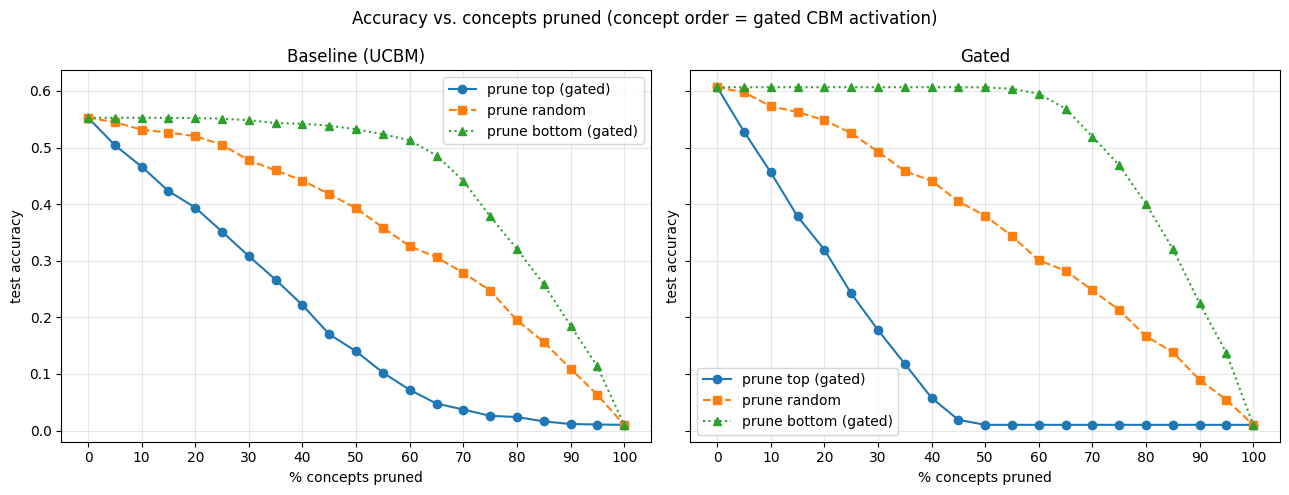

In [12]:
mean_act  = gated_sims.abs().mean(dim=0)          # mean of |activation| per concept
top_order  = mean_act.argsort(descending=True).tolist()      # most → least active
bot_order  = mean_act.argsort(descending=False).tolist()     # least → most active

targets = torch.tensor(dataset.targets)

def accuracy_after_pruning(sims, pruned_ids, linear, device):
    s = sims.clone()
    if pruned_ids:
        s[:, pruned_ids] = 0.0
    with torch.no_grad():
        logits = linear(s.to(device)).cpu()
    return (logits.argmax(dim=1) == targets).float().mean().item()

# 3. Sweep over number of pruned concepts
num_concepts = baseline_cbm._num_concepts
ks = list(range(0, num_concepts + 1, num_concepts // 20))   # 20 steps

np.random.seed(42)
rand_order = np.random.permutation(num_concepts).tolist()

results = {label: [] for label in [
    "baseline_top", "baseline_random", "baseline_bottom",
    "gated_top",    "gated_random",    "gated_bottom",
]}

percentages = list(range(0, 101, 5))  # 0%, 5%, ..., 100%

for pct in percentages:
    k = int(pct / 100 * num_concepts)
    for name, cbm, sims in [("baseline", baseline_cbm, baseline_sims),
                              ("gated",    gated_cbm,    gated_sims)]:
        lin = cbm._classifier.linear
        dev = cbm._device
        results[f"{name}_top"].append(
            accuracy_after_pruning(sims, top_order[:k],  lin, dev))
        results[f"{name}_bottom"].append(
            accuracy_after_pruning(sims, bot_order[:k],  lin, dev))
        results[f"{name}_random"].append(
            accuracy_after_pruning(sims, rand_order[:k], lin, dev))

# 4. Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
styles = {
    "top":    dict(marker="o", linestyle="-",  label="prune top (gated)"),
    "random": dict(marker="s", linestyle="--", label="prune random"),
    "bottom": dict(marker="^", linestyle=":",  label="prune bottom (gated)"),
}
for ax, name, title in zip(axes, ["baseline", "gated"], ["Baseline (UCBM)", "Gated"]):
    for condition, style in styles.items():
        ax.plot(percentages, results[f"{name}_{condition}"], **style)
    ax.set_xlabel("% concepts pruned")
    ax.set_xticks(range(0, 101, 10))
    ax.set_ylabel("test accuracy")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Accuracy vs. concepts pruned (concept order = gated CBM activation)")
plt.tight_layout()
plt.show()


In [13]:
print("top 5 mean acts:", mean_act[top_order[:5]])
print("bot 5 mean acts:", mean_act[bot_order[:5]])

top 5 mean acts: tensor([0.7976, 0.7866, 0.7817, 0.7781, 0.7768])
bot 5 mean acts: tensor([0.0085, 0.0086, 0.0087, 0.0089, 0.0089])


## Plot number of concepts used

In [14]:
gates = torch.sigmoid(gated_cbm._classifier.gate_logits).detach().cpu()
retained_gated = (gates > 0.5).nonzero().squeeze().tolist()
print(f"Gated retains {len(retained_gated)} / {gated_cbm._num_concepts} concepts")

Gated retains 463 / 1000 concepts


In [15]:
retained_baseline = (baseline_sims.mean(dim=0) > 0).nonzero().squeeze().tolist()
print(f"Baseline retains {len(retained_baseline)} / {baseline_cbm._num_concepts} concepts")

Baseline retains 1000 / 1000 concepts


PERCENTILE = 0.75  # "higher" threshold = top quartile of each model's own positive activations, fit on train

for name, cbm in [("baseline", baseline_cbm_cub), ("gated", gated_cbm_cub)]:
    cbm.fit_concept_attribute_mapping(train_data_cub, ACT_BANK_PATH_CUB, "train")

    train_acts = cbm._get_concept_activations(train_data_cub, ACT_BANK_PATH_CUB, "train")
    threshold = train_acts[train_acts > 0].quantile(PERCENTILE).item()

    result = cbm.concept_accuracy(test_data_cub, ACT_BANK_PATH_CUB, "test", activation_threshold=threshold)
    print(f"{name} (threshold={threshold:.3f}): {result}")

## Concept Accuracy (CUB)

In [5]:
DATASET_CUB = 'cub'
BACKBONE_CUB = 'cub_rn18'
CON_BANK_NAME_CUB = 'concepts_200_64'
PARENT_DIR_CUB = path.join(RESULT_PATH, f'{DATASET_CUB}-{BACKBONE_CUB}/classifier/{CON_BANK_NAME_CUB}')
ACT_BANK_PATH_CUB = path.join(RESULT_PATH, f'{DATASET_CUB}-{BACKBONE_CUB}/concept_data/{CON_BANK_NAME_CUB}')

model_cub = get_model(BACKBONE_CUB, device)

# non-gated / gated CUB runs, identified via each classifier.pth's saved "gated" flag
baseline_cbm_cub = UCBM.load_from_file(
    filepath=path.join(PARENT_DIR_CUB, 'topk_seed_0-2026_07_17_-_04_19_47'),
    filename='classifier.pth')
gated_cbm_cub = UCBM.load_from_file(
    filepath=path.join(PARENT_DIR_CUB, 'topk_seed_0-2026_07_17_-_04_35_36'),
    filename='classifier.pth')

train_data_cub = load_data('cub', True, model_cub.transform, load_attributes=True)
test_data_cub = load_data('cub', False, model_cub.transform, load_attributes=True)

In [6]:
for name, cbm in [("baseline", baseline_cbm_cub), ("gated", gated_cbm_cub)]:
    cbm.fit_concept_attribute_mapping(train_data_cub, ACT_BANK_PATH_CUB, "train")
    result = cbm.concept_accuracy(test_data_cub, ACT_BANK_PATH_CUB, "test")
    print(f"{name}: {result}")

baseline: {'concept accuracy': 0.1914636641740799, 'avg predicted concepts': 64.13341522216797, 'images with predictions': 5794}
gated: {'concept accuracy': 0.1826755702495575, 'avg predicted concepts': 99.2438735961914, 'images with predictions': 5794}
